In [4]:
import re
import numpy as np
import pandas as pd
import itertools
from tqdm.auto import tqdm

import matplotlib.pyplot as plt


from bert_score import score
import pymorphy3
from rapidfuzz.distance import Levenshtein
from sacrebleu.metrics import BLEU, CHRF


import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [5]:
files = {
    0.0: "c2_augmented_11_llama3_temp_0_0.csv",
    0.1: "c2_augmented_11_llama3_temp_0_1.csv",
    0.2: "c2_augmented_11_llama3_temp_0_2.csv",
    0.3: "c2_augmented_11_llama3_temp_0_3.csv",
    0.4: "c2_augmented_11_llama3_temp_0_4.csv",
    0.5: "c2_augmented_11_llama3_temp_0_5.csv",
    0.6: "c2_augmented_11_llama3_temp_0_6.csv",
    0.7: "c2_augmented_11_llama3_temp_0_7.csv",
    0.8: "c2_augmented_11_llama3_temp_0_8.csv",
    0.9: "c2_augmented_11_llama3_temp_0_9.csv",
    1.0: "c2_augmented_11_llama3_temp_1_0.csv",
    1.1: "c2_augmented_11_llama3_temp_1_1.csv",
    1.2: "c2_augmented_11_llama3_temp_1_2.csv",
    1.3: "c2_augmented_11_llama3_temp_1_3.csv",
    1.4: "c2_augmented_11_llama3_temp_1_4.csv",
    1.5: "c2_augmented_11_llama3_temp_1_5.csv",
}

# Вспомогательные функции подсчета метрик

In [6]:
morph = pymorphy3.MorphAnalyzer()

def tokenize_words(text):
    text = str(text).lower()
    return re.findall(r"[а-яёa-z]+", text)


def lemmatize_text(text):
    words = tokenize_words(text)
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [7]:
def bertscore_pair(original_text, augmented_text, model_type="DeepPavlov/rubert-base-cased"):
    P, R, F1 = score(
        [augmented_text],      
        [original_text],       
        model_type=model_type,
        num_layers=12,
        lang="ru",
        verbose=False
    )

    return {
        "precision": P.item(),
        "recall": R.item(),
        "f1": F1.item()
    }

In [8]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()


def jaccard_similarity_lemmas(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas and not aug_lemmas:
        return 1.0

    if not orig_lemmas or not aug_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas | aug_lemmas)


def common_words_ratio(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas)


def normalized_levenshtein_distance(original, augmented):
    original = str(original)
    augmented = str(augmented)

    max_len = max(len(original), len(augmented))

    if max_len == 0:
        return 0.0

    distance = Levenshtein.distance(original, augmented)
    return distance / max_len


def normalized_levenshtein_similarity(original, augmented):
    return 1 - normalized_levenshtein_distance(original, augmented)

In [9]:
def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_f1(original, augmented):
    orig_tokens = tokenize_words(original)
    aug_tokens = tokenize_words(augmented)

    if not orig_tokens or not aug_tokens:
        return 0.0

    lcs = lcs_length(orig_tokens, aug_tokens)

    precision = lcs / len(aug_tokens)
    recall = lcs / len(orig_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [10]:
def bleu_score(original, augmented):
    score = bleu_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100


def chrf_score(original, augmented):
    score = chrf_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100

# Сравнение исходных и аугментированных текстов внутри одной температуры

In [11]:
def calculate_pair_metrics(original, augmented):
    return {
        "bert_score": bertscore_pair(original, augmented),
        "jaccard_lemmas": jaccard_similarity_lemmas(original, augmented),
        "common_words_ratio": common_words_ratio(original, augmented),
        "levenshtein_distance": normalized_levenshtein_distance(original, augmented),
        "levenshtein_similarity": normalized_levenshtein_similarity(original, augmented),
        "rouge_l": rouge_l_f1(original, augmented),
        "bleu": bleu_score(original, augmented),
        "chrf": chrf_score(original, augmented),
    }

In [12]:
all_rows = []

for temp, path in files.items():
    df = pd.read_csv(path)

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Обработка строк"):
        original = row['text']
        augmented = row['augmented-text']

        metrics = calculate_pair_metrics(original, augmented)

        metrics["temperature"] = temp
        metrics["original"] = original
        metrics["augmented"] = augmented

        all_rows.append(metrics)

pair_metrics_df = pd.DataFrame(all_rows)

pair_metrics_df

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

...

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

,bert_score,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature,original,augmented
0,"{'precision': 0.8608617186546326, 'recall': 0....",0.612903,0.791667,0.240223,0.759777,0.760000,0.579216,0.777603,0.0,"3:38–3:54 Собственно, сама по себе радиация не...",4:38–4:54 В природе сама радиация не заразна. ...
1,"{'precision': 0.8182154893875122, 'recall': 0....",0.656250,0.807692,0.378723,0.621277,0.690909,0.398773,0.754795,0.0,Недавно компания Uber объявила об инвестиции о...,Компания Uber объявила о вложении миллиарда до...
2,"{'precision': 0.7409124374389648, 'recall': 0....",0.354839,0.550000,0.486772,0.513228,0.418605,0.170983,0.543362,0.0,"Множество повестей: «Двойник», «Дядюшкин сон»,...",Многообразие литературных жанров: романы «Двой...
3,"{'precision': 0.5824538469314575, 'recall': 0....",0.181818,0.333333,0.557940,0.442060,0.226415,0.040907,0.368673,0.0,Встречи одноклассников и одногруппников превра...,Встречи с одноклассниками и одногруппниками тр...
4,"{'precision': 0.6633508801460266, 'recall': 0....",0.191489,0.333333,0.531136,0.468864,0.295082,0.093365,0.450379,0.0,Самопрезентация — как главная черта времени и ...,Самопрезентация - это доминирующая характерист...
...,...,...,...,...,...,...,...,...,...,...,...
1915,"{'precision': 0.7768507599830627, 'recall': 0....",0.500000,0.708333,0.418803,0.581197,0.642857,0.379678,0.607651,1.5,00:00:24 А сегодня испытания. 13 участников. Ж...,00:00:24 Сегодня состязания. 13 участников. Жю...
1916,"{'precision': 0.5705910921096802, 'recall': 0....",0.295455,0.481481,0.623932,0.376068,0.266667,0.086319,0.440282,1.5,«Прома» способна предложить дилерам вполне бож...,"Дилеры могут получить от компании ""Прома"" сног..."
1917,"{'precision': 0.7397317886352539, 'recall': 0....",0.515152,0.708333,0.533654,0.466346,0.480000,0.424137,0.605644,1.5,Tesla — не единственный игрок на рынке: больши...,"Большинство ведущих автопроизводителей — Ford,..."
1918,"{'precision': 0.583713173866272, 'recall': 0.6...",0.302326,0.500000,0.577406,0.422594,0.456140,0.158767,0.485841,1.5,"Понятно, что среди крупнейших стран – поставщи...",Среди ведущих стран-поставщиков высококачестве...


In [13]:
pair_metrics_df['bert_score_precision'] = [pair_metrics_df['bert_score'][i]['precision'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_recall'] = [pair_metrics_df['bert_score'][i]['recall'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_f1'] = [pair_metrics_df['bert_score'][i]['f1'] for i in range(len(pair_metrics_df))]

del pair_metrics_df['bert_score']

pair_metrics_df

,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature,original,augmented,bert_score_precision,bert_score_recall,bert_score_f1
0,0.612903,0.791667,0.240223,0.759777,0.760000,0.579216,0.777603,0.0,"3:38–3:54 Собственно, сама по себе радиация не...",4:38–4:54 В природе сама радиация не заразна. ...,0.860862,0.853239,0.857034
1,0.656250,0.807692,0.378723,0.621277,0.690909,0.398773,0.754795,0.0,Недавно компания Uber объявила об инвестиции о...,Компания Uber объявила о вложении миллиарда до...,0.818215,0.834852,0.826450
2,0.354839,0.550000,0.486772,0.513228,0.418605,0.170983,0.543362,0.0,"Множество повестей: «Двойник», «Дядюшкин сон»,...",Многообразие литературных жанров: романы «Двой...,0.740912,0.789333,0.764357
3,0.181818,0.333333,0.557940,0.442060,0.226415,0.040907,0.368673,0.0,Встречи одноклассников и одногруппников превра...,Встречи с одноклассниками и одногруппниками тр...,0.582454,0.552259,0.566955
4,0.191489,0.333333,0.531136,0.468864,0.295082,0.093365,0.450379,0.0,Самопрезентация — как главная черта времени и ...,Самопрезентация - это доминирующая характерист...,0.663351,0.682703,0.672888
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,0.500000,0.708333,0.418803,0.581197,0.642857,0.379678,0.607651,1.5,00:00:24 А сегодня испытания. 13 участников. Ж...,00:00:24 Сегодня состязания. 13 участников. Жю...,0.776851,0.790234,0.783485
1916,0.295455,0.481481,0.623932,0.376068,0.266667,0.086319,0.440282,1.5,«Прома» способна предложить дилерам вполне бож...,"Дилеры могут получить от компании ""Прома"" сног...",0.570591,0.591577,0.580894
1917,0.515152,0.708333,0.533654,0.466346,0.480000,0.424137,0.605644,1.5,Tesla — не единственный игрок на рынке: больши...,"Большинство ведущих автопроизводителей — Ford,...",0.739732,0.769621,0.754380
1918,0.302326,0.500000,0.577406,0.422594,0.456140,0.158767,0.485841,1.5,"Понятно, что среди крупнейших стран – поставщи...",Среди ведущих стран-поставщиков высококачестве...,0.583713,0.619069,0.600871


In [14]:
metric_columns = [
    "bert_score_precision",
    "bert_score_recall",
    "bert_score_f1",
    "jaccard_lemmas",
    "common_words_ratio",
    "levenshtein_distance",
    "levenshtein_similarity",
    "rouge_l",
    "bleu",
    "chrf",
]

results_df = (
    pair_metrics_df
    .groupby("temperature")[metric_columns]
    .agg(["mean", "std", "min", "max"])
)

In [15]:
results_df_flat = results_df.copy()

results_df_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in results_df_flat.columns
]

results_df_flat = results_df_flat.reset_index()

In [16]:
results_df['bert_score_precision']

,mean,std,min,max
temperature,,,,
0.0,0.800833,0.099228,0.581341,0.983900
0.1,0.805459,0.096961,0.572681,0.993253
0.2,0.799564,0.094659,0.548479,0.983900
0.3,0.793892,0.106690,0.422799,0.983900
0.4,0.787391,0.101533,0.507650,0.983900
0.5,0.789930,0.094950,0.530403,0.994051
0.6,0.775199,0.114472,0.472377,0.983900
0.7,0.757570,0.093212,0.499484,0.936338
0.8,0.755067,0.110021,0.419274,1.000000


In [17]:
results_df['bert_score_recall']

,mean,std,min,max
temperature,,,,
0.0,0.787659,0.106564,0.512174,0.983244
0.1,0.791874,0.109463,0.466244,0.993253
0.2,0.788281,0.102096,0.535338,0.979566
0.3,0.782404,0.115550,0.382909,0.979566
0.4,0.772838,0.112516,0.504244,0.979566
0.5,0.775623,0.104662,0.485628,0.987430
0.6,0.766754,0.118665,0.412870,0.979566
0.7,0.746867,0.100952,0.460362,0.946351
0.8,0.748670,0.110148,0.387140,1.000000


In [18]:
results_df['bert_score_f1']

,mean,std,min,max
temperature,,,,
0.0,0.793714,0.101487,0.545472,0.983244
0.1,0.798013,0.101770,0.517898,0.993253
0.2,0.793490,0.097130,0.543626,0.981728
0.3,0.787543,0.109737,0.410902,0.981728
0.4,0.779532,0.105725,0.507362,0.981728
0.5,0.782033,0.097809,0.515050,0.990729
0.6,0.770327,0.114988,0.460717,0.981728
0.7,0.751486,0.095075,0.498684,0.937994
0.8,0.751209,0.108439,0.420746,1.000000


In [19]:
results_df['jaccard_lemmas']

,mean,std,min,max
temperature,,,,
0.0,0.557920,0.184714,0.181818,1.000000
0.1,0.566096,0.188133,0.166667,1.000000
0.2,0.558073,0.175221,0.238095,1.000000
0.3,0.550873,0.183801,0.180000,1.000000
0.4,0.536154,0.174174,0.148148,1.000000
0.5,0.546196,0.183064,0.180000,1.000000
0.6,0.526300,0.197288,0.095238,1.000000
0.7,0.487085,0.170146,0.114286,0.913043
0.8,0.486715,0.185449,0.117647,1.000000


In [20]:
results_df['common_words_ratio']

,mean,std,min,max
temperature,,,,
0.0,0.697810,0.154563,0.333333,1.000000
0.1,0.706980,0.163052,0.214286,1.000000
0.2,0.701749,0.147932,0.380952,1.000000
0.3,0.694857,0.162164,0.285714,1.000000
0.4,0.680808,0.154211,0.250000,1.000000
0.5,0.692065,0.149638,0.333333,1.000000
0.6,0.670621,0.179363,0.142857,1.000000
0.7,0.639626,0.156454,0.190476,0.923077
0.8,0.639353,0.169657,0.210526,1.000000


In [21]:
results_df['levenshtein_distance']

,mean,std,min,max
temperature,,,,
0.0,0.356943,0.167930,0.004878,0.808081
0.1,0.347412,0.169624,0.034653,0.756757
0.2,0.356236,0.163491,0.034653,0.810526
0.3,0.372099,0.176778,0.034653,0.825397
0.4,0.382685,0.179267,0.019512,0.821053
0.5,0.363421,0.161103,0.005747,0.797297
0.6,0.397673,0.180850,0.025641,0.815476
0.7,0.406624,0.152340,0.068627,0.808642
0.8,0.410864,0.160509,0.000000,0.787356


In [22]:
results_df['levenshtein_similarity']

,mean,std,min,max
temperature,,,,
0.0,0.643057,0.167930,0.191919,0.995122
0.1,0.652588,0.169624,0.243243,0.965347
0.2,0.643764,0.163491,0.189474,0.965347
0.3,0.627901,0.176778,0.174603,0.965347
0.4,0.617315,0.179267,0.178947,0.980488
0.5,0.636579,0.161103,0.202703,0.994253
0.6,0.602327,0.180850,0.184524,0.974359
0.7,0.593376,0.152340,0.191358,0.931373
0.8,0.589136,0.160509,0.212644,1.000000


In [23]:
results_df['rouge_l']

,mean,std,min,max
temperature,,,,
0.0,0.618548,0.178803,0.160000,1.000000
0.1,0.631498,0.181088,0.090909,0.976744
0.2,0.616961,0.174872,0.222222,1.000000
0.3,0.604032,0.187196,0.176471,0.960000
0.4,0.586814,0.187148,0.146341,0.978723
0.5,0.608328,0.175236,0.160000,1.000000
0.6,0.572293,0.203741,0.076923,0.960000
0.7,0.544870,0.170493,0.139535,0.931034
0.8,0.545083,0.184057,0.083333,1.000000


In [24]:
results_df['bleu']

,mean,std,min,max
temperature,,,,
0.0,0.387215,0.228135,0.022452,0.929924
0.1,0.397570,0.230473,0.021321,0.942025
0.2,0.378537,0.223132,0.025612,0.929924
0.3,0.380788,0.229470,0.030864,0.929924
0.4,0.350864,0.225371,0.022452,0.929924
0.5,0.364941,0.224399,0.022452,0.934304
0.6,0.336296,0.222295,0.015622,0.929924
0.7,0.296733,0.191508,0.022452,0.843898
0.8,0.308553,0.211004,0.024780,1.000000


In [25]:
results_df['chrf']

,mean,std,min,max
temperature,,,,
0.0,0.646140,0.149178,0.317197,0.985482
0.1,0.652268,0.155757,0.225155,0.961898
0.2,0.642502,0.145847,0.314512,0.961898
0.3,0.635977,0.156276,0.311733,0.961898
0.4,0.626614,0.151859,0.300463,0.985482
0.5,0.636231,0.155015,0.227526,0.976826
0.6,0.610614,0.163181,0.186402,0.961898
0.7,0.589303,0.138754,0.187192,0.927431
0.8,0.588484,0.156872,0.240626,1.000000


In [26]:
def plot_metric(results_df, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.plot(
        results_df["temperature"],
        results_df[f"{metric_name}_mean"],
        marker="o"
    )

    plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
    plt.xlabel("Температура генерации")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()

    plt.show()

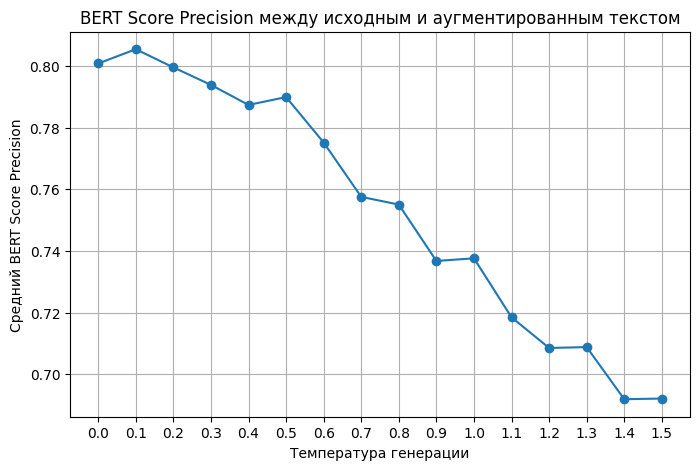

In [27]:
plot_metric(
    results_df_flat,
    "bert_score_precision",
    "BERT Score Precision между исходным и аугментированным текстом",
    "Средний BERT Score Precision"
)

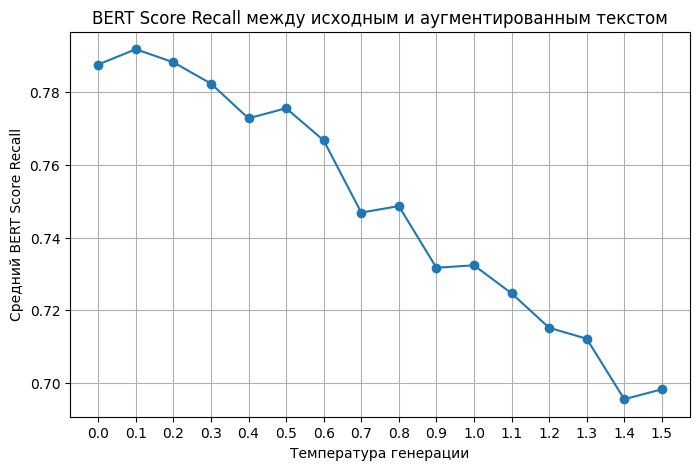

In [28]:
plot_metric(
    results_df_flat,
    "bert_score_recall",
    "BERT Score Recall между исходным и аугментированным текстом",
    "Средний BERT Score Recall"
)

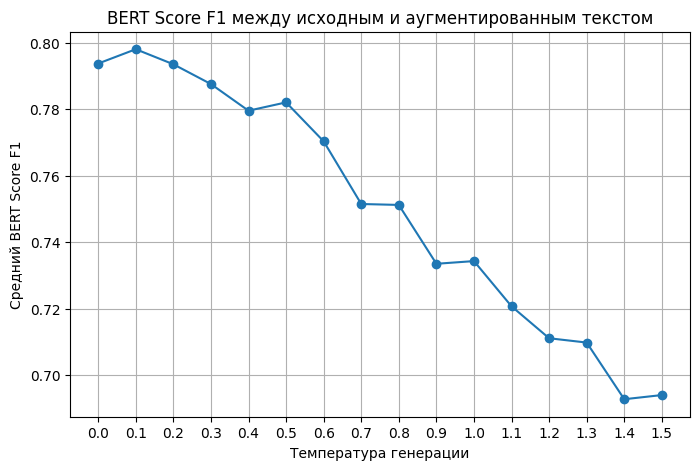

In [29]:
plot_metric(
    results_df_flat,
    "bert_score_f1",
    "BERT Score F1 между исходным и аугментированным текстом",
    "Средний BERT Score F1"
)

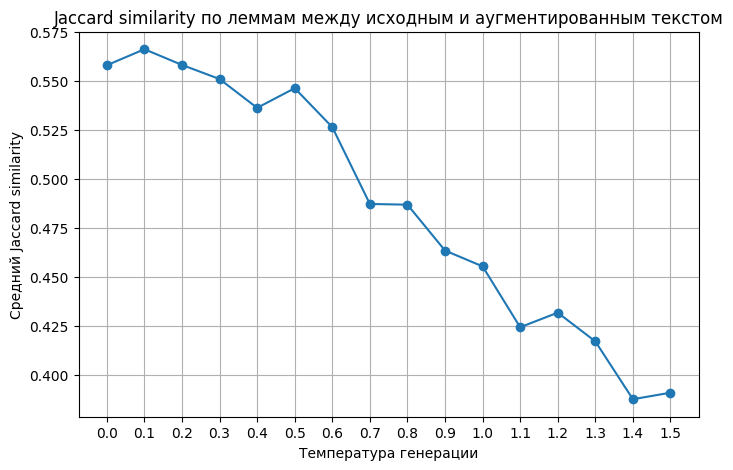

In [30]:
plot_metric(
    results_df_flat,
    "jaccard_lemmas",
    "Jaccard similarity по леммам между исходным и аугментированным текстом",
    "Средний Jaccard similarity"
)

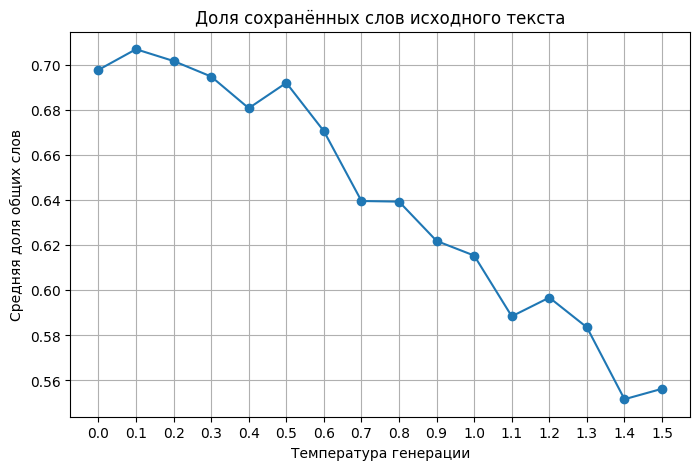

In [31]:
plot_metric(
    results_df_flat,
    "common_words_ratio",
    "Доля сохранённых слов исходного текста",
    "Средняя доля общих слов"
)


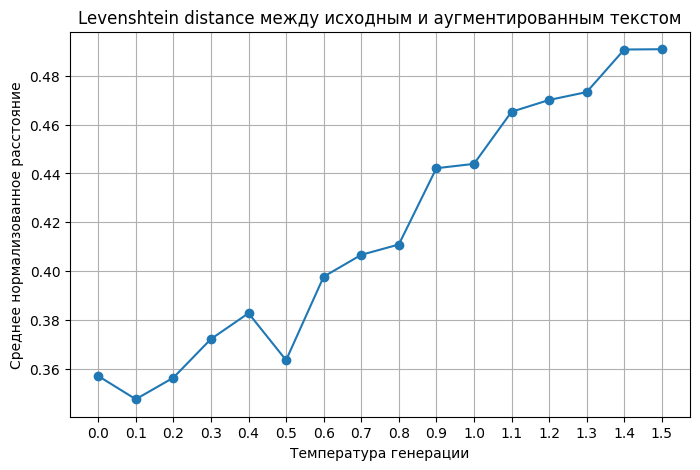

In [32]:
plot_metric(
    results_df_flat,
    "levenshtein_distance",
    "Levenshtein distance между исходным и аугментированным текстом",
    "Среднее нормализованное расстояние"
)

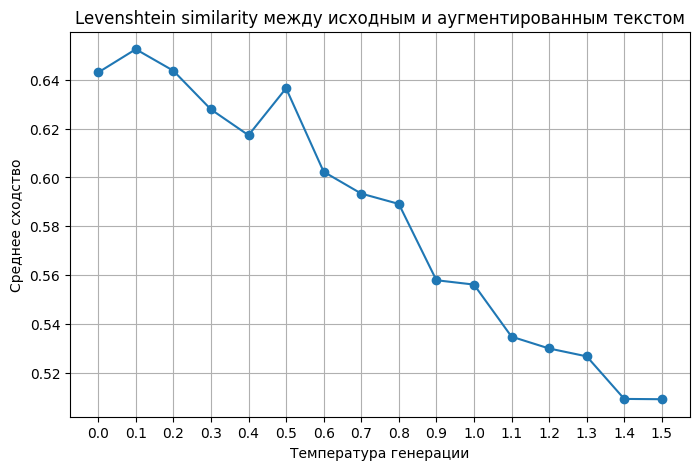

In [33]:
plot_metric(
    results_df_flat,
    "levenshtein_similarity",
    "Levenshtein similarity между исходным и аугментированным текстом",
    "Среднее сходство"
)

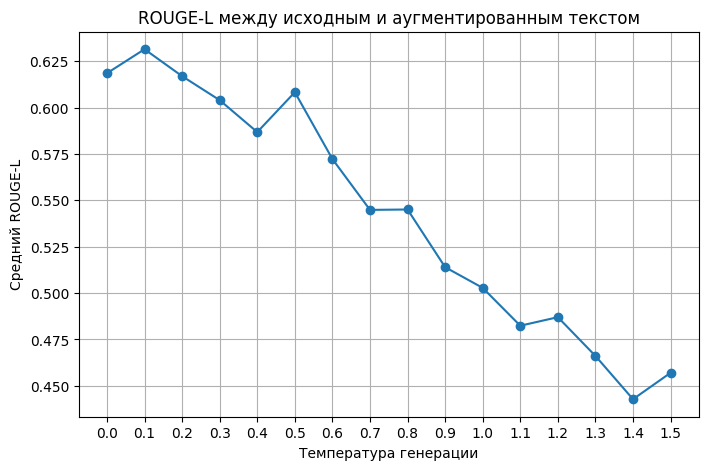

In [34]:
plot_metric(
    results_df_flat,
    "rouge_l",
    "ROUGE-L между исходным и аугментированным текстом",
    "Средний ROUGE-L"
)

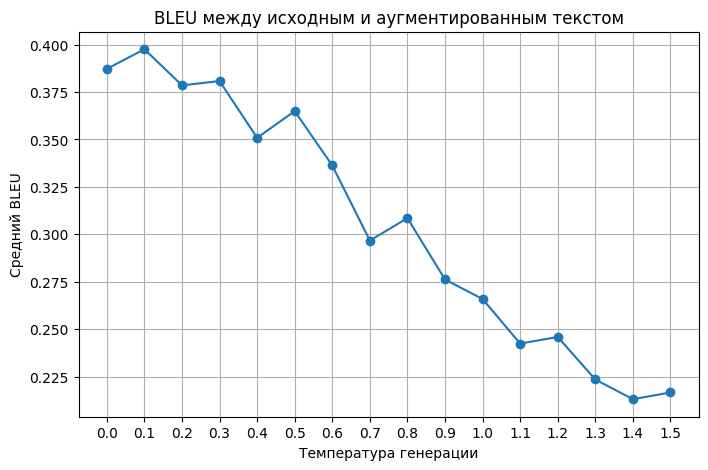

In [35]:
plot_metric(
    results_df_flat,
    "bleu",
    "BLEU между исходным и аугментированным текстом",
    "Средний BLEU"
)

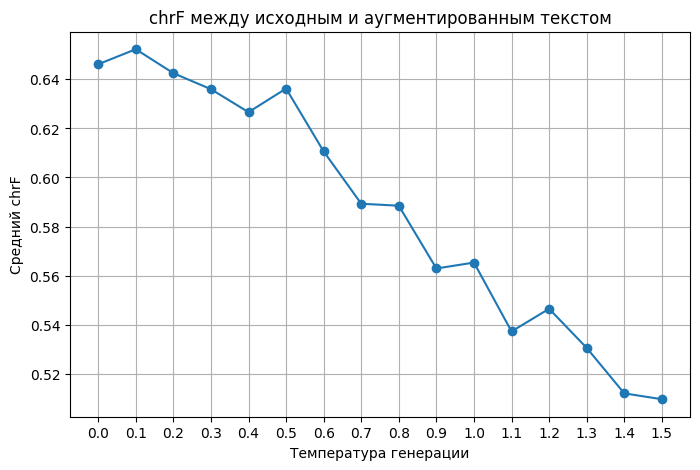

In [36]:
plot_metric(
    results_df_flat,
    "chrf",
    "chrF между исходным и аугментированным текстом",
    "Средний chrF"
)